# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/samanashfaq05/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [6]:
!git clone https://github.com/samanashfaq05/flyrank-ml-internship.git
%cd /content/flyrank-ml-internship

!pip install -q datasets

from datasets import load_dataset
import pandas as pd

ds = load_dataset(
    "FlyRank/internship-lanes",
    "decline_recovery"
)

print(ds)

for split in ds.keys():
    df = ds[split].to_pandas()

    print("\n" + "=" * 70)
    print("SPLIT:", split)
    print("Rows:", len(df))
    print("\nCOLUMNS:")
    print(df.columns.tolist())

    print("\nFIRST 5 ROWS:")
    print(df.head().to_string())

    print("\nDATA TYPES:")
    print(df.dtypes)

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (200/200), done.
remote: Compressing objects: 100% (148/148), done.
remote: Total 200 (delta 97), reused 101 (delta 36), pack-reused 0 (from 0)
Receiving objects: 100% (200/200), 1.89 MiB | 7.44 MiB/s, done.
Resolving deltas: 100% (97/97), done.
/content/flyrank-ml-internship


README.md:   0%|          | 0.00/2.98k [00:00<?, ?B/s]

default_lanes/decline_recovery.parquet: reconstructing file:   0%|          |  0.00B / 3.88MB            

default_lanes/decline_recovery.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/56253 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['client_hash_id', 'content_hash_id', 'keyword_hash_id', 'keyword_char_count', 'keyword_token_count', 'public_url_hash_id', 'public_url_char_count', 'public_url_path_depth', 'content_title_hash_id', 'content_title_char_count', 'content_title_token_count', 'impressions_90d', 'clicks_90d', 'sum_position_90d', 'sessions_90d', 'pageviews_90d', 'ai_sessions_90d', 'scroll_events_90d', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'client_has_gsc', 'client_has_ga4', 'content_type', 'content_created_at', 'content_age_days', 'ctr_90d', 'avg_position_90d', 'ai_traffic_pct_90d', 'scroll_rate_90d', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining'],
        num_rows: 56253
    })
})

SPLIT: train
Rows: 56253

COLUMNS:
['client_hash_id', 'co

In [7]:
df = ds["train"].to_pandas().copy()

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Clients:", df["client_hash_id"].nunique())
print("Declining rate:", round(df["is_declining"].mean(), 3))

Rows: 56253
Columns: 43
Clients: 46
Declining rate: 1.0


## 1. Question

*The research question and the decision it supports.*

# Problem framing

## Research question

Among content records that are already experiencing declining search performance, can observable content characteristics and historical performance signals help identify records experiencing severe decline, so editors can prioritize them for review and recovery?

## Decision supported

The analysis supports the decision of which declining content records should be investigated first.

## Unit of analysis

Each row represents a content record.

## Output

The model will produce a probability-based severe-decline score that can be used to rank content records for editor review.

## Action

A FlyRank editor could use the ranked output to investigate high-priority records and decide whether content refresh, SEO review, CTR improvements, or another recovery action is appropriate.

## Cost of wrong calls

A false positive may cause unnecessary editor review.

A false negative may cause a severely declining content record to receive attention too late.

## Why ML helps

The decision depends on multiple interacting signals, including historical search performance, traffic, engagement, content characteristics, and age. These relationships may be difficult to represent with a single hand-written rule, so machine learning may help prioritize records for human review.

## Claim boundary

This project provides decision-support based on observed patterns in the dataset. It does not prove why search performance declined and does not predict Google's algorithm.

In [8]:
import numpy as np

# Calculate observed percentage change in impressions
df["impression_change_pct"] = (
    (
        df["impressions_last_30d"]
        - df["impressions_prev_30d"]
    )
    / df["impressions_prev_30d"]
) * 100

# Define severe decline as a drop of 60% or more
df["severe_decline"] = (
    df["impression_change_pct"] <= -60
).astype(int)

print("CAPSTONE TARGET")
print("=" * 70)

print("Target: severe_decline")
print("Definition: impression change <= -60%")

print("\nSevere decline records:", df["severe_decline"].sum())
print(
    "Severe decline rate:",
    round(df["severe_decline"].mean(), 3)
)

print("\nNon-severe decline records:")
print((df["severe_decline"] == 0).sum())

CAPSTONE TARGET
Target: severe_decline
Definition: impression change <= -60%

Severe decline records: 26093
Severe decline rate: 0.464

Non-severe decline records:
30160


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# Data safety

The dataset contains pseudonymous identifiers, performance metrics, content characteristics, and derived recommendation fields.

I use observable content characteristics and historical performance signals as candidate features.

I deliberately exclude all pseudonymous identifiers:

- client_hash_id
- content_hash_id
- keyword_hash_id
- public_url_hash_id
- content_title_hash_id

These columns are identifiers rather than meaningful predictive features. `client_hash_id` will only be used for grouped train/test splitting.

I also exclude label-derived fields:

- trend_direction
- trend_pct
- is_declining

These fields directly describe decline and could cause target leakage.

The target `severe_decline` is derived from the percentage change between `impressions_prev_30d` and `impressions_last_30d`. Therefore, those two columns and `impression_change_pct` are excluded from model features to prevent direct target leakage.

I also exclude derived recommendation or outcome-style fields:

- health_score
- needs_indexing
- is_quick_win
- needs_ctr_fix
- needs_engagement_fix
- ai_opportunity
- is_underperformer

These fields may contain business rules or downstream assessments rather than independent observable signals.

The model will therefore use only selected observable performance, traffic, engagement, content, and structural characteristics available independently of the severe-decline target.

No client-identifying information will be used as a model feature or included in the final recommendations.

In [9]:
# ============================================================
# SECTION 2: DATA SAFETY AND FEATURE SELECTION
# ============================================================

# Pseudonymous identifier columns
id_cols = [
    "client_hash_id",
    "content_hash_id",
    "keyword_hash_id",
    "public_url_hash_id",
    "content_title_hash_id",
]

# Columns directly related to decline or used to define the target
leakage_cols = [
    "trend_direction",
    "trend_pct",
    "is_declining",
    "impression_change_pct",
    "impressions_prev_30d",
    "impressions_last_30d",
]

# Derived recommendation / outcome-style columns
derived_cols = [
    "health_score",
    "needs_indexing",
    "is_quick_win",
    "needs_ctr_fix",
    "needs_engagement_fix",
    "ai_opportunity",
    "is_underperformer",
]

# Other non-feature columns
non_feature_cols = [
    "content_created_at",
    "severe_decline"
]

# Combine all excluded columns
excluded_cols = (
    id_cols
    + leakage_cols
    + derived_cols
    + non_feature_cols
)

# Keep only columns that actually exist
excluded_cols = [
    col for col in excluded_cols
    if col in df.columns
]

# Candidate model features
feature_cols = [
    col for col in df.columns
    if col not in excluded_cols
]

print("DATA SAFETY CHECK")
print("=" * 70)

print("\nTotal columns:", len(df.columns))

print("\nExcluded columns:", len(excluded_cols))
for col in excluded_cols:
    print("-", col)

print("\nCandidate model features:", len(feature_cols))
for col in feature_cols:
    print("-", col)

print("\nIdentifier columns used as features:")
print(any(col in feature_cols for col in id_cols))

print("\nLeakage columns used as features:")
print(any(col in feature_cols for col in leakage_cols))

DATA SAFETY CHECK

Total columns: 45

Excluded columns: 20
- client_hash_id
- content_hash_id
- keyword_hash_id
- public_url_hash_id
- content_title_hash_id
- trend_direction
- trend_pct
- is_declining
- impression_change_pct
- impressions_prev_30d
- impressions_last_30d
- health_score
- needs_indexing
- is_quick_win
- needs_ctr_fix
- needs_engagement_fix
- ai_opportunity
- is_underperformer
- content_created_at
- severe_decline

Candidate model features: 25
- keyword_char_count
- keyword_token_count
- public_url_char_count
- public_url_path_depth
- content_title_char_count
- content_title_token_count
- impressions_90d
- clicks_90d
- sum_position_90d
- sessions_90d
- pageviews_90d
- ai_sessions_90d
- scroll_events_90d
- clicks_last_30d
- sessions_last_30d
- clicks_prev_30d
- sessions_prev_30d
- client_has_gsc
- client_has_ga4
- content_type
- content_age_days
- ctr_90d
- avg_position_90d
- ai_traffic_pct_90d
- scroll_rate_90d

Identifier columns used as features:
False

Leakage columns

In [10]:
# ============================================================
# FEATURE TYPE CHECK
# ============================================================

feature_df = df[feature_cols].copy()

print("FEATURE DATA TYPES")
print("=" * 70)

print(feature_df.dtypes.value_counts())

categorical_features = feature_df.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

numeric_features = feature_df.select_dtypes(
    include=["number"]
).columns.tolist()

print("\nNumeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical / boolean features:", len(categorical_features))
print(categorical_features)

print("\nMissing values:")
missing = feature_df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

FEATURE DATA TYPES
int64      14
float64     8
bool        2
object      1
Name: count, dtype: int64

Numeric features: 22
['keyword_char_count', 'keyword_token_count', 'public_url_char_count', 'public_url_path_depth', 'content_title_char_count', 'content_title_token_count', 'impressions_90d', 'clicks_90d', 'sum_position_90d', 'sessions_90d', 'pageviews_90d', 'ai_sessions_90d', 'scroll_events_90d', 'clicks_last_30d', 'sessions_last_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'ctr_90d', 'avg_position_90d', 'ai_traffic_pct_90d', 'scroll_rate_90d']

Categorical / boolean features: 3
['client_has_gsc', 'client_has_ga4', 'content_type']

Missing values:
ai_traffic_pct_90d    14896
scroll_rate_90d       14849
pageviews_90d         13598
sessions_90d          13598
scroll_events_90d     13598
ai_sessions_90d       13598
dtype: int64


### Data safety observations

After excluding identifiers, label-derived fields, target-related columns, and derived recommendation fields, 25 candidate features remain: 22 numeric features and 3 categorical or boolean features.

Several traffic and engagement features contain missing values. Instead of removing a large number of records, missing numeric values will be imputed during preprocessing. The categorical feature `content_type` will be encoded without using pseudonymous identifiers.

The grouped client identifier will be retained only for the train/test split and will never be used as a model feature.

This preprocessing design aims to prevent direct target leakage while preserving useful observable information.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# Transparent baseline

Before training a machine learning model, I build a simple rule-based baseline that a human can understand.

The baseline prioritizes a content record when:

1. Its recent impressions are lower than its previous impressions.
2. Its average search position is relatively weak.
3. It previously had meaningful search visibility.

Each condition contributes one point to a transparent priority score. The records are ranked by this score.

This baseline is intentionally simple. The Random Forest model will only be useful if it can improve prioritization compared with this transparent rule on the same grouped holdout data and using the same Precision@50 metric.

In [11]:
from sklearn.model_selection import GroupShuffleSplit

# Features
X = df[feature_cols].copy()

# Target
y = df["severe_decline"].copy()

# Grouping variable - used ONLY for splitting
groups = df["client_hash_id"]

# Client-level split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("GROUPED TRAIN/TEST SPLIT")
print("=" * 70)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining clients:", groups.iloc[train_idx].nunique())
print("Test clients:", groups.iloc[test_idx].nunique())

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("Clients appearing in both:", len(train_clients & test_clients))

print("\nTraining severe decline rate:", round(y_train.mean(), 3))
print("Test severe decline rate:", round(y_test.mean(), 3))

GROUPED TRAIN/TEST SPLIT
Training rows: 48219
Test rows: 8034

Training clients: 36
Test clients: 10
Clients appearing in both: 0

Training severe decline rate: 0.454
Test severe decline rate: 0.524


In [12]:
import numpy as np

# ============================================================
# TRANSPARENT RULE-BASED BASELINE
# ============================================================

baseline_df = df.iloc[test_idx].copy()

# Rule 1:
# Recent impressions are lower than previous impressions
recent_decline = (
    baseline_df["impressions_last_30d"]
    < baseline_df["impressions_prev_30d"]
).astype(int)

# Rule 2:
# Weak search position
weak_position = (
    baseline_df["avg_position_90d"] > 20
).astype(int)

# Rule 3:
# Previously meaningful visibility
meaningful_visibility = (
    baseline_df["impressions_prev_30d"] >= 500
).astype(int)

# Transparent baseline score
baseline_df["baseline_score"] = (
    recent_decline
    + weak_position
    + meaningful_visibility
)

# Reason codes
def get_reason(row):
    reasons = []

    if row["impressions_last_30d"] < row["impressions_prev_30d"]:
        reasons.append("recent_impression_drop")

    if row["avg_position_90d"] > 20:
        reasons.append("weak_position")

    if row["impressions_prev_30d"] >= 500:
        reasons.append("meaningful_visibility")

    return "|".join(reasons)

baseline_df["reason_code"] = baseline_df.apply(
    get_reason,
    axis=1
)

# Rank pages
baseline_df = baseline_df.sort_values(
    "baseline_score",
    ascending=False
).reset_index(drop=True)

baseline_df["rank"] = baseline_df.index + 1

print("BASELINE SCORE DISTRIBUTION")
print("=" * 70)

print(baseline_df["baseline_score"].value_counts().sort_index())

print("\nTOP 10 BASELINE RECOMMENDATIONS")
print("=" * 70)

print(
    baseline_df[
        [
            "rank",
            "baseline_score",
            "reason_code",
            "impressions_prev_30d",
            "impressions_last_30d",
            "avg_position_90d",
            "severe_decline"
        ]
    ].head(10).to_string(index=False)
)

BASELINE SCORE DISTRIBUTION
baseline_score
1    2310
2    4421
3    1303
Name: count, dtype: int64

TOP 10 BASELINE RECOMMENDATIONS
 rank  baseline_score                                                reason_code  impressions_prev_30d  impressions_last_30d  avg_position_90d  severe_decline
    1               3 recent_impression_drop|weak_position|meaningful_visibility                   630                    69              21.2               1
    2               3 recent_impression_drop|weak_position|meaningful_visibility                   577                   353              30.7               0
    3               3 recent_impression_drop|weak_position|meaningful_visibility                   609                   353              23.1               0
    4               3 recent_impression_drop|weak_position|meaningful_visibility                   576                    67              46.4               1
    5               3 recent_impression_drop|weak_position|meaningful_vis

In [13]:
# ============================================================
# RECREATE BASELINE + EVALUATE
# ============================================================

import numpy as np

# Create test dataframe
test_df = df.iloc[test_idx].copy()

# Rule 1: recent impressions dropped
recent_decline = (
    test_df["impressions_last_30d"]
    < test_df["impressions_prev_30d"]
).astype(int)

# Rule 2: weak search position
weak_position = (
    test_df["avg_position_90d"] > 20
).astype(int)

# Rule 3: meaningful previous visibility
meaningful_visibility = (
    test_df["impressions_prev_30d"] >= 500
).astype(int)

# Create transparent baseline score
test_df["baseline_score"] = (
    recent_decline
    + weak_position
    + meaningful_visibility
)

# Precision@K function
def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    top_k_labels = np.asarray(labels)[order[:k]]
    return top_k_labels.mean()

k = 50

baseline_precision_at_50 = precision_at_k(
    test_df["baseline_score"],
    test_df["severe_decline"],
    k=k
)

test_base_rate = test_df["severe_decline"].mean()

print("BASELINE EVALUATION")
print("=" * 70)
print(f"Baseline Precision@{k}:",
      round(baseline_precision_at_50, 3))
print("Test severe decline base rate:",
      round(test_base_rate, 3))

print("\nScore distribution:")
print(test_df["baseline_score"].value_counts().sort_index())

BASELINE EVALUATION
Baseline Precision@50: 0.72
Test severe decline base rate: 0.524

Score distribution:
baseline_score
1    2310
2    4421
3    1303
Name: count, dtype: int64


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*



A Random Forest classifier is used to predict the probability that an already-declining content record belongs to the severe-decline group.

Random Forest was selected because the problem contains multiple numerical, categorical, traffic, engagement, and content features that may interact in non-linear ways.

The model uses only the safe features selected in Section 2. Missing numeric values are imputed with the median, missing categorical values are replaced with the most frequent value, and categorical variables are one-hot encoded.

The model is evaluated on the same client-level holdout split used for the transparent baseline. Performance is compared using Precision@50 and the test-set base rate.

In [14]:
# ============================================================
# SECTION 4: RANDOM FOREST MODEL
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Numeric preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Complete pipeline
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

# Train model
model_pipeline.fit(X_train, y_train)

# Predict probabilities on SAME test split
model_scores = model_pipeline.predict_proba(X_test)[:, 1]

print("MODEL TRAINING COMPLETE")
print("=" * 70)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Features before encoding:", len(feature_cols))

MODEL TRAINING COMPLETE
Training rows: 48219
Test rows: 8034
Features before encoding: 25


In [15]:
# ============================================================
# MODEL VS BASELINE EVALUATION
# ============================================================

# Model Precision@50
model_precision_at_50 = precision_at_k(
    model_scores,
    y_test,
    k=50
)

# Base rate
test_base_rate = y_test.mean()

# Comparison table
comparison = pd.DataFrame({
    "Method": [
        "Test base rate",
        "Transparent baseline",
        "Random Forest"
    ],
    "Precision@50": [
        test_base_rate,
        baseline_precision_at_50,
        model_precision_at_50
    ]
})

# Calculate lift over baseline
model_lift = model_precision_at_50 - baseline_precision_at_50

print("MODEL VS BASELINE")
print("=" * 70)

print(comparison.to_string(index=False))

print("\nModel lift over baseline:",
      round(model_lift, 3))

print("\nRandom Forest Precision@50:",
      round(model_precision_at_50, 3))

print("Baseline Precision@50:",
      round(baseline_precision_at_50, 3))

print("Test base rate:",
      round(test_base_rate, 3))

MODEL VS BASELINE
              Method  Precision@50
      Test base rate      0.523525
Transparent baseline      0.720000
       Random Forest      1.000000

Model lift over baseline: 0.28

Random Forest Precision@50: 1.0
Baseline Precision@50: 0.72
Test base rate: 0.524


### Interpretation

On the same client-level holdout split, the Random Forest achieved a Precision@50 of 1.000 compared with 0.720 for the transparent baseline and a severe-decline base rate of 0.524.

This means that all of the top 50 records ranked by the model were severe-decline records on this particular test split. The model improved Precision@50 by 0.280 compared with the baseline.

This result should be interpreted as measured performance on this holdout split rather than proof that the model will always achieve perfect performance on new clients or future data.

## 5. Limitations

*What this work cannot claim.*

This analysis has several important limitations.

1. **Single dataset and client-level split:** The results were measured on one grouped holdout split. Performance may differ for another group of clients or future data.

2. **Precision@50 is limited to the top-ranked records:** A Random Forest Precision@50 of 1.000 means that the top 50 records were correctly identified as severe declines on this test split. It does not mean that the model perfectly classifies every record.

3. **Target definition is threshold-based:** The target `severe_decline` was defined using an observed impression change threshold of -60%. This threshold is a practical proxy for prioritization and does not represent a universal definition of content failure.

4. **No causal claims:** The model identifies patterns associated with severe decline but cannot determine why a decline happened. The analysis cannot claim that a particular content characteristic caused a decline.

5. **Historical performance signals:** The model is based on available historical search, traffic, engagement, and content signals. Changes in search behavior or future conditions may reduce performance over time.

6. **Decision-support only:** The output should be used to prioritize editor review rather than automatically making content changes. A high-risk score is a recommendation for investigation, not proof that a page should be refreshed.

7. **Data limitations:** The dataset contains anonymized and aggregated signals, so the analysis cannot incorporate additional contextual information that might help explain individual content performance.

Overall, the results should be interpreted as observed and directional decision-support evidence rather than a prediction of Google's ranking algorithm or a guarantee of future performance.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final model output is converted into a ranked action list for editorial decision-support. Records are ranked by their predicted probability of severe decline so that a FlyRank editor can investigate the highest-risk records first.

Priority levels are assigned based on the model's predicted probability:

- High priority: probability >= 0.80
- Medium priority: probability >= 0.60 and < 0.80
- Low priority: probability < 0.60

For high-priority records, the recommended action is immediate editorial review for possible content refresh or recovery action. Each recommendation includes supporting performance context and a confidence note.

These recommendations are not automatic instructions to change content. The model is intended to support prioritization, while a human editor should review the underlying content and performance context before making changes. Confidence reflects the model's ranking score rather than certainty that a specific intervention will improve performance.

In [16]:
# ============================================================
# SECTION 6: RANKED RECOMMENDATIONS
# ============================================================

# Create recommendation dataframe from the SAME test set
recommendations = df.iloc[test_idx].copy()

# Add model probability score
recommendations["model_score"] = model_scores

# Create priority levels
recommendations["priority"] = pd.cut(
    recommendations["model_score"],
    bins=[-0.01, 0.60, 0.80, 1.0],
    labels=["Low", "Medium", "High"]
)

# Recommended action
recommendations["recommended_action"] = np.select(
    [
        recommendations["model_score"] >= 0.80,
        recommendations["model_score"] >= 0.60
    ],
    [
        "Review immediately for possible refresh or recovery action",
        "Review after high-priority records"
    ],
    default="Monitor performance before taking action"
)

# Confidence explanation
recommendations["confidence_note"] = np.select(
    [
        recommendations["model_score"] >= 0.80,
        recommendations["model_score"] >= 0.60
    ],
    [
        "High predicted probability of severe decline",
        "Moderate predicted probability of severe decline"
    ],
    default="Lower predicted probability of severe decline"
)

# Sort by highest predicted risk
recommendations = recommendations.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

# Add rank
recommendations["rank"] = range(1, len(recommendations) + 1)

# Display top recommendations
output_cols = [
    "rank",
    "model_score",
    "priority",
    "recommended_action",
    "confidence_note",
    "impressions_prev_30d",
    "impressions_last_30d",
    "avg_position_90d",
    "severe_decline"
]

print("TOP 20 RANKED RECOMMENDATIONS")
print("=" * 100)

print(
    recommendations[output_cols]
    .head(20)
    .to_string(index=False)
)

TOP 20 RANKED RECOMMENDATIONS
 rank  model_score priority                                         recommended_action                              confidence_note  impressions_prev_30d  impressions_last_30d  avg_position_90d  severe_decline
    1        0.990     High Review immediately for possible refresh or recovery action High predicted probability of severe decline                   107                     3               9.7               1
    2        0.985     High Review immediately for possible refresh or recovery action High predicted probability of severe decline                   130                     3               9.0               1
    3        0.985     High Review immediately for possible refresh or recovery action High predicted probability of severe decline                   132                     7               9.1               1
    4        0.985     High Review immediately for possible refresh or recovery action High predicted probability of severe declin

In [23]:
# ============================================================
# SAVE RANKED RECOMMENDATIONS
# ============================================================

import os

os.makedirs("work/outputs", exist_ok=True)

recommendations_path = "work/outputs/capstone_ranked_recommendations.csv"

top20.to_csv(
    recommendations_path,
    index=False
)

print("RANKED RECOMMENDATIONS SAVED")
print("=" * 70)
print("Output file:", recommendations_path)
print("Rows saved:", len(top20))

RANKED RECOMMENDATIONS SAVED
Output file: work/outputs/capstone_ranked_recommendations.csv
Rows saved: 20


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

This section generates the charts and tables used to communicate the capstone results. The artifacts summarize the dataset target distribution, model performance compared with the transparent baseline, feature importance, and the final ranked recommendations.

These artifacts are descriptive and support interpretation of the measured results. They are intended for the deployed research paper and decision-support presentation.

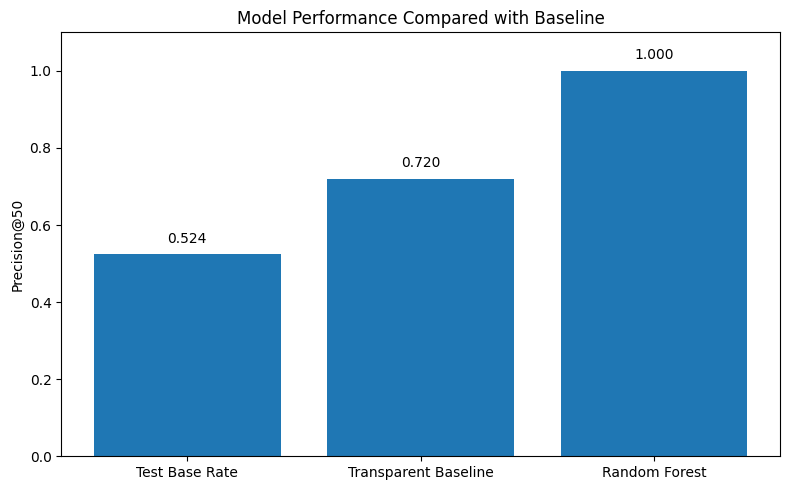

ARTIFACT SAVED
Saved: work/outputs/model_vs_baseline.png


In [25]:
# ============================================================
# ARTIFACT 1: MODEL VS BASELINE
# ============================================================

import matplotlib.pyplot as plt
import os

os.makedirs("work/outputs", exist_ok=True)

# Measured results from the evaluation section
test_base_rate = 0.524
baseline_precision = 0.72
random_forest_precision = 1.0

methods = [
    "Test Base Rate",
    "Transparent Baseline",
    "Random Forest"
]

scores = [
    test_base_rate,
    baseline_precision,
    random_forest_precision
]

plt.figure(figsize=(8, 5))
plt.bar(methods, scores)

plt.ylabel("Precision@50")
plt.title("Model Performance Compared with Baseline")
plt.ylim(0, 1.1)

for i, value in enumerate(scores):
    plt.text(i, value + 0.03, f"{value:.3f}", ha="center")

plt.tight_layout()

output_path = "work/outputs/model_vs_baseline.png"

plt.savefig(output_path, dpi=300)
plt.show()

print("ARTIFACT SAVED")
print("=" * 70)
print("Saved:", output_path)

## Artifact 2 — Feature Importance

This chart shows the most influential features used by the Random Forest model. Feature importance helps interpret which observable signals contributed most to the model's ranking decisions.

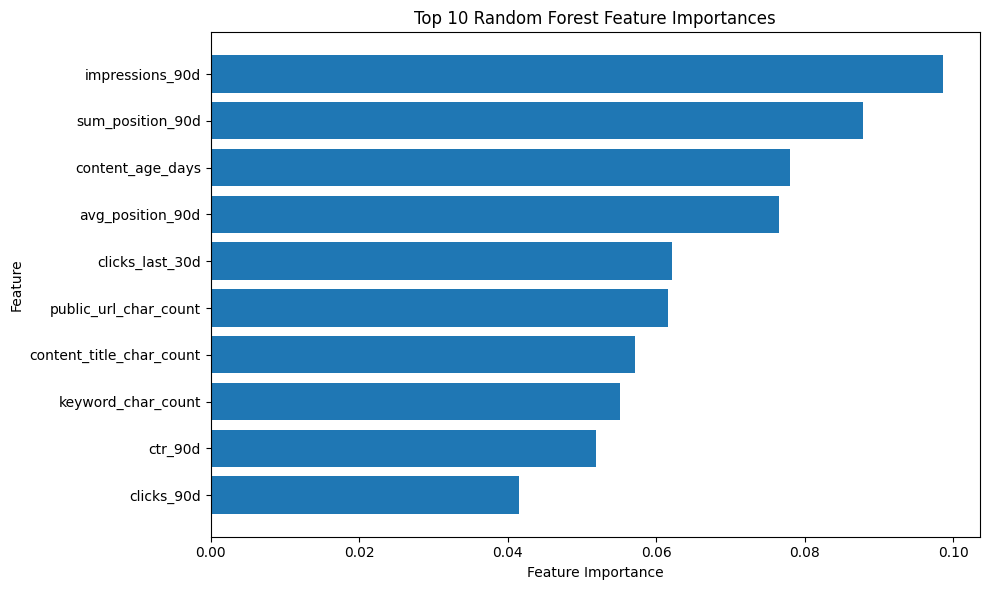

ARTIFACT SAVED
Saved: work/outputs/top_feature_importances.png

Top 10 Features:
                 feature  importance
         impressions_90d    0.098681
        sum_position_90d    0.087901
        content_age_days    0.078003
        avg_position_90d    0.076532
         clicks_last_30d    0.062182
   public_url_char_count    0.061557
content_title_char_count    0.057147
      keyword_char_count    0.055072
                 ctr_90d    0.051947
              clicks_90d    0.041589


In [27]:
# ============================================================
# ARTIFACT 2: TOP 10 FEATURE IMPORTANCES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Recreate training and test data
X_train_artifact = X.iloc[train_idx].copy()
X_test_artifact = X.iloc[test_idx].copy()
y_train_artifact = y.iloc[train_idx].copy()

# Identify feature types
numeric_features = X_train_artifact.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train_artifact.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

# Preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Random Forest pipeline
artifact_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

# Train model
artifact_model.fit(X_train_artifact, y_train_artifact)

# Get transformed feature names
feature_names = artifact_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importances
importances = artifact_model.named_steps[
    "model"
].feature_importances_

feature_importance_artifact = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Remove preprocessing prefixes for readability
feature_importance_artifact["feature"] = (
    feature_importance_artifact["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_features = feature_importance_artifact.sort_values(
    "importance",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.tight_layout()

output_path = "work/outputs/top_feature_importances.png"

plt.savefig(output_path, dpi=300)
plt.show()

print("ARTIFACT SAVED")
print("=" * 70)
print("Saved:", output_path)

print("\nTop 10 Features:")
print(top_features.to_string(index=False))

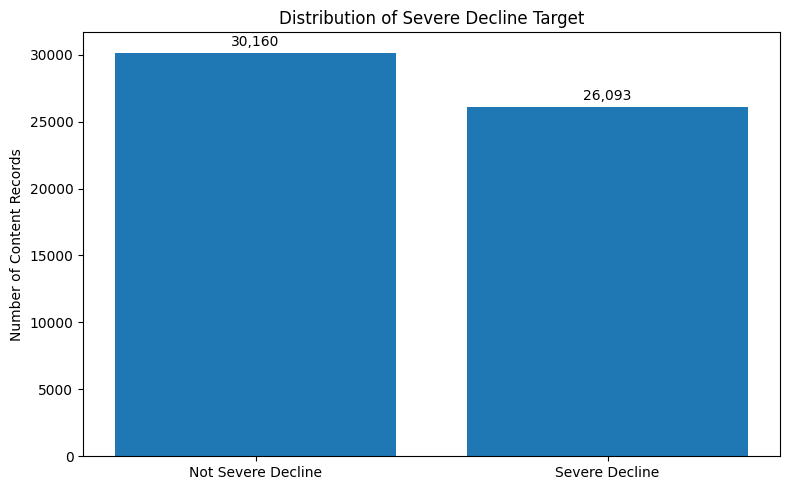

ARTIFACT SAVED
Saved: work/outputs/severe_decline_distribution.png

Target distribution:
Not Severe Decline: 30,160
Severe Decline: 26,093


In [28]:
# ============================================================
# ARTIFACT 3: SEVERE DECLINE TARGET DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt
import os

# Count target classes
target_counts = df["severe_decline"].value_counts().sort_index()

labels = ["Not Severe Decline", "Severe Decline"]

values = [
    target_counts.get(0, 0),
    target_counts.get(1, 0)
]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.ylabel("Number of Content Records")
plt.title("Distribution of Severe Decline Target")

for i, value in enumerate(values):
    plt.text(
        i,
        value + 500,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()

output_path = "work/outputs/severe_decline_distribution.png"

plt.savefig(output_path, dpi=300)
plt.show()

print("ARTIFACT SAVED")
print("=" * 70)
print("Saved:", output_path)

print("\nTarget distribution:")
print("Not Severe Decline:", f"{values[0]:,}")
print("Severe Decline:", f"{values[1]:,}")

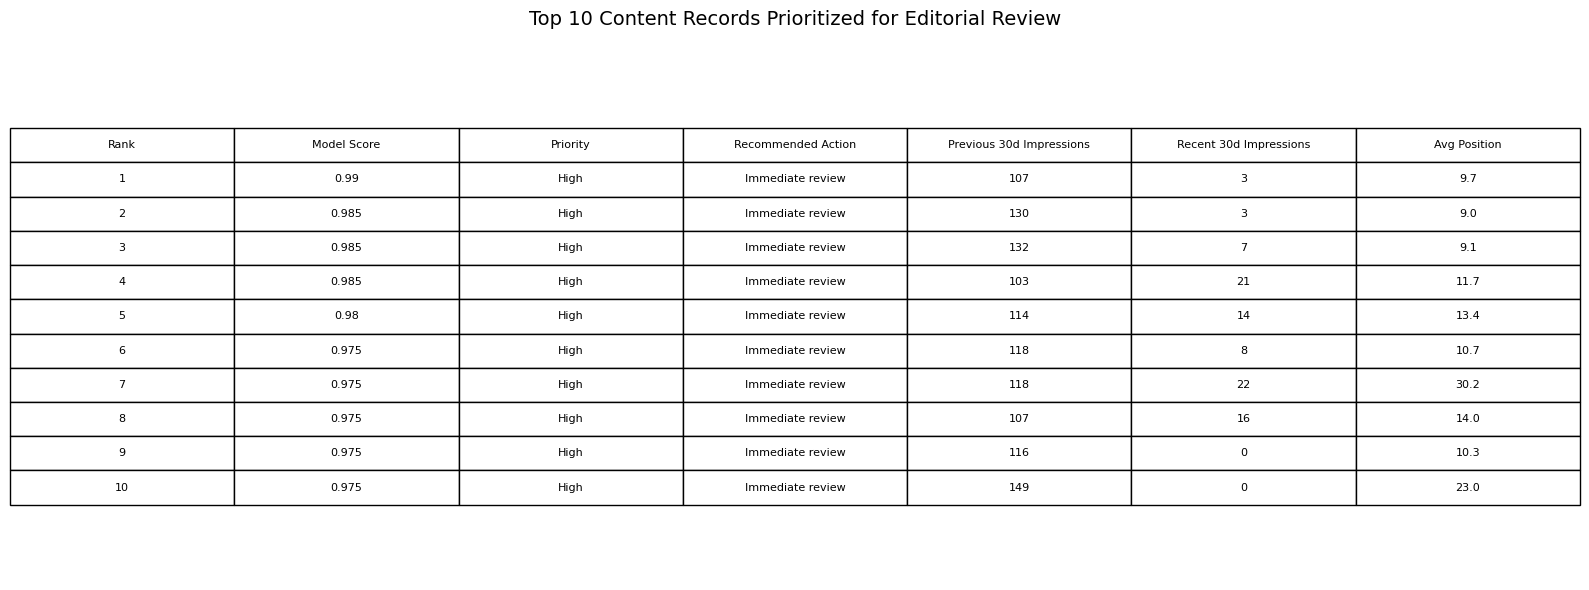

ARTIFACT SAVED
Saved: work/outputs/top10_ranked_recommendations.png

Top 10 recommendations:
 Rank  Model Score Priority Recommended Action  Previous 30d Impressions  Recent 30d Impressions  Avg Position
    1        0.990     High   Immediate review                       107                       3           9.7
    2        0.985     High   Immediate review                       130                       3           9.0
    3        0.985     High   Immediate review                       132                       7           9.1
    4        0.985     High   Immediate review                       103                      21          11.7
    5        0.980     High   Immediate review                       114                      14          13.4
    6        0.975     High   Immediate review                       118                       8          10.7
    7        0.975     High   Immediate review                       118                      22          30.2
    8        0.975 

In [29]:
# ============================================================
# ARTIFACT 4: TOP 10 RANKED RECOMMENDATIONS TABLE
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import os

# Select columns for presentation
table_cols = [
    "rank",
    "model_score",
    "priority",
    "recommended_action",
    "impressions_prev_30d",
    "impressions_last_30d",
    "avg_position_90d"
]

# Create Top 10 table
top10_table = top20[table_cols].head(10).copy()

# Round model score
top10_table["model_score"] = top10_table["model_score"].round(3)

# Shorten action text for display
top10_table["recommended_action"] = (
    top10_table["recommended_action"]
    .replace(
        "Review immediately for possible refresh or recovery action",
        "Immediate review"
    )
)

# Rename columns for clean presentation
top10_table = top10_table.rename(columns={
    "rank": "Rank",
    "model_score": "Model Score",
    "priority": "Priority",
    "recommended_action": "Recommended Action",
    "impressions_prev_30d": "Previous 30d Impressions",
    "impressions_last_30d": "Recent 30d Impressions",
    "avg_position_90d": "Avg Position"
})

# Create figure
fig, ax = plt.subplots(figsize=(16, 6))

ax.axis("off")

table = ax.table(
    cellText=top10_table.values,
    colLabels=top10_table.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.8)

plt.title(
    "Top 10 Content Records Prioritized for Editorial Review",
    fontsize=14,
    pad=20
)

plt.tight_layout()

# Save artifact
output_path = "work/outputs/top10_ranked_recommendations.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("ARTIFACT SAVED")
print("=" * 70)
print("Saved:", output_path)

print("\nTop 10 recommendations:")
print(
    top10_table.to_string(index=False)
)

## 8. Reproducibility

This capstone was developed using the FlyRank ML Internship dataset in the `decline_recovery` lane.

### Environment

- Python: 3.13.15
- Pandas: 2.2.3
- NumPy: 2.1.3
- Scikit-learn: 1.6.1

### Reproducible setup

The repository can be cloned and the analysis can be rerun using the same dataset and workflow.

```bash
git clone https://github.com/samanashfaq05/flyrank-ml-internship.git
cd flyrank-ml-internship

In [30]:
# ============================================================
# SECTION 8: REPRODUCIBILITY INFORMATION
# ============================================================

import sys
import sklearn
import pandas as pd
import numpy as np

print("REPRODUCIBILITY INFORMATION")
print("=" * 70)

print("Python version:", sys.version.split()[0])
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Scikit-learn version:", sklearn.__version__)

print("\nRandom seed:")
print("42")

print("\nDataset:")
print("FlyRank ML Internship dataset")
print("Lane: decline_recovery")

print("\nMain method:")
print("Random Forest Classifier")

print("\nEvaluation:")
print("Client-level grouped train/test split")
print("Test size: 20%")
print("Metric: Precision@50")

REPRODUCIBILITY INFORMATION
Python version: 3.13.15
Pandas version: 2.2.3
NumPy version: 2.1.3
Scikit-learn version: 1.6.1

Random seed:
42

Dataset:
FlyRank ML Internship dataset
Lane: decline_recovery

Main method:
Random Forest Classifier

Evaluation:
Client-level grouped train/test split
Test size: 20%
Metric: Precision@50


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
